In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import NearestNeighbors

In [2]:
def create_dataset(n_samples=200):
    noise_scale = 5
    x1_f1 = np.linspace(10, 60, n_samples)
    f1 = -0.04 * (x1_f1 - 35)**2 + 80 + np.random.normal(0, noise_scale, n_samples)
    x1_f2 = np.linspace(40, 90, n_samples)
    f2 = 0.04 * (x1_f2 - 65)**2 + 20 + np.random.normal(0, noise_scale, n_samples)

    x1_all = np.concatenate([x1_f1, x1_f2])
    x2_all = np.concatenate([f1, f2])

    dataset = pd.DataFrame({
        "x1": x1_all,
        "x2": x2_all
    })
    return dataset

In [3]:
class NeighbourClusterer:
    def __init__(self, n_neighbors=5, splitting_z_score=3):
        self.n_neighbors = n_neighbors
        self.splitting_z_score = splitting_z_score

    def fit(self, df):
        dataset = df.copy()
        gr = nx.Graph()

        gr.add_nodes_from(dataset.index)

        nn_model = NearestNeighbors(n_neighbors=self.n_neighbors)
        nn_model.fit(dataset)
        distances, indices = nn_model.kneighbors(dataset)

        idx_mapper = dataset.index.tolist()

        for i, neighbors_list in enumerate(indices):
            node_id = idx_mapper[i]
            for j, neighbor_pos in enumerate(neighbors_list):
                if j > 0:
                    neighbor_id = idx_mapper[neighbor_pos]
                    weight = distances[i][j]
                    gr.add_edge(node_id, neighbor_id, weight=weight)

        connected_components = list(nx.connected_components(gr))
        dataset["cls"] = -1

        for i, component in enumerate(connected_components):
            dataset.loc[list(component), "cls"] = (i + 1)

        return dataset
    def plot(self, df):
        plt.figure(figsize=(12, 8))
        unique_cls = sorted(df["cls"].unique())
        colors = plt.cm.get_cmap('tab10', len(unique_cls))

        for i, cls_name in enumerate(unique_cls):
            subset = df[df["cls"] == cls_name]
            plt.scatter(
                subset["x1"],
                subset["x2"],
                color=colors(i),
                label=f"Class {cls_name}",
                alpha=0.7
            )

        plt.legend(title="Sınıflar")

In [4]:
df = create_dataset()
n_clusterer = NeighbourClusterer()
classed_df = n_clusterer.fit(df)
classed_df.head()

,x1,x2,cls
0,10.000000,50.759360,1
1,10.251256,55.142919,1
2,10.502513,57.667630,1
3,10.753769,57.372594,1
4,11.005025,55.454543,1


In [5]:
classed_df["cls"].value_counts()

,count
cls,
1,200
2,200


/tmp/ipykernel_9802/1992701773.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_cls))


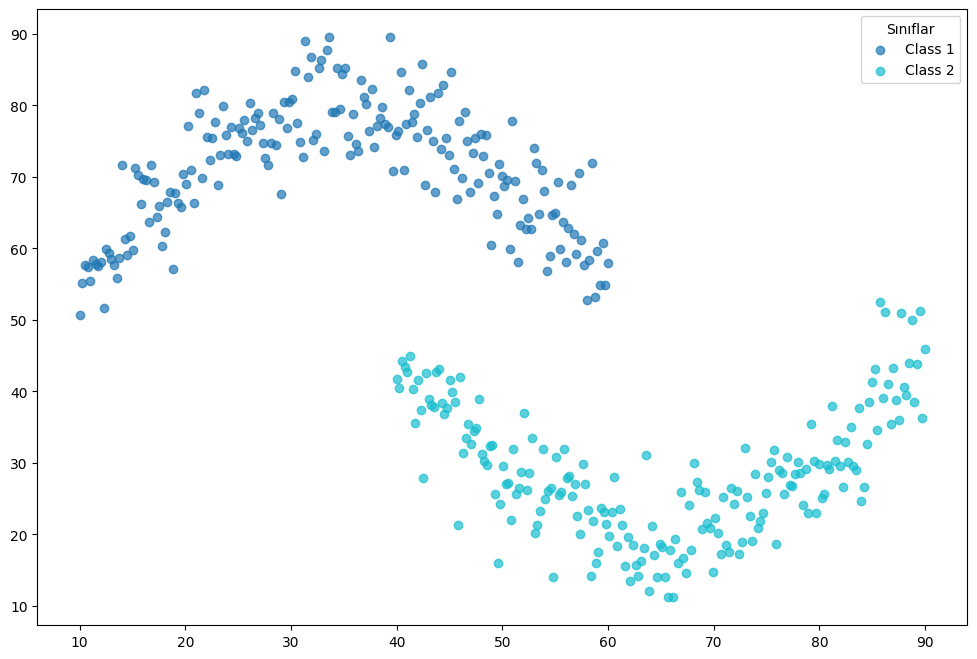

In [6]:
n_clusterer.plot(classed_df)